<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>Ensemble</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score
from sklearn.pipeline import Pipeline

In [2]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display
from scripts.decision_tree import determine_parameter

In [3]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [4]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [5]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [8]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [9]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=True)),
            ('scaler', MinMaxScaler())
        ])
)

In [10]:
X_train = transformer.fit_transform(X_train)

In [11]:
X_test = transformer.transform(X_test)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. PCA</h2>
</div>

In [12]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [13]:
pca = PCA()

In [14]:
X_pca = pca.fit_transform(X_train)

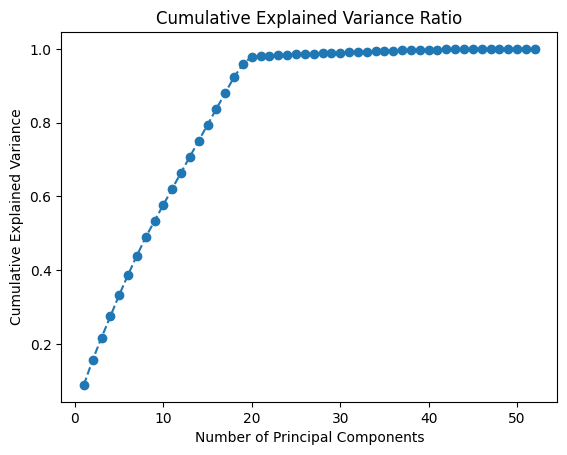

In [15]:
# Plot explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o' , linestyle='--')
plt.title('Cumulative Explained Variance Ratio') 
plt.xlabel('Number of Principal Components') 
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [16]:
# Determine the optimal number of components based on the explained variance
n_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to retain 95% variance: {n_components}")

Number of components to retain 95% variance: 19


In [17]:
pipeline = Pipeline([
    ('pca', PCA(n_components=n_components)),  # Reduce dimensions using PCA
     ('model', LogisticRegression(C=0.1))
])

In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pca', PCA(n_components=19)),
                ('model', LogisticRegression(C=0.1))])

In [19]:
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

print(f'{"Training Accuracy:":<20}{train_acc:.2f}')
print(f'{"Test Accuracy:":<20}{test_acc:.2f}')

y_test_pred = pipeline.predict(X_test)
print(f'{"Recall Score:":<20}{recall_score(y_test, y_test_pred, pos_label=1):.2f}')
print(f'{"Precision Score:":<20}{precision_score(y_test, y_test_pred, pos_label=1):.2f}')
print(f'{"RoC AuC Score:":<20}{roc_auc_score(y_test, y_test_pred):.2f}')
f1 = f1_score(y_test, y_test_pred, pos_label=1)
print(f'{"F1 Score:":<20}{f1:.2}')

Training Accuracy:  0.88
Test Accuracy:      0.89
Recall Score:       0.03
Precision Score:    0.58
RoC AuC Score:      0.51
F1 Score:           0.048


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>4. Ensemble</h2>
</div>

In [20]:
from catboost import CatBoostClassifier

In [21]:
pipeline = Pipeline([
    ('pca', PCA(n_components=n_components)),  # Reduce dimensions using PCA
    ('model', CatBoostClassifier(class_weights={0:1, 1:9}, random_state=42, verbose=0))  # Train Logistic Regression model
])

In [22]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pca', PCA(n_components=19)),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7f5f59ffa610>)])

In [33]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
print(f"{'Recall Score:':<20}{rs:.3}")
print(f"{'Precision Score:':<20}{ps:.3}")
print(f"{'F1 Score:':<20}{f1:.3}")
print(f"{'ROC AUC Score:':<20}{roc:.3}")
print(f"{'Accuracy Score:':<20}{ac:.3}")

Recall Score:       0.675
Precision Score:    0.217
F1 Score:           0.328
ROC AUC Score:      0.678
Accuracy Score:     0.68


In [24]:
y_pred = pipeline.predict(X_test)

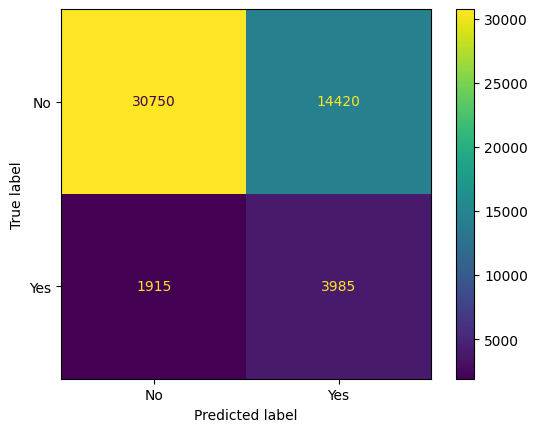

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [27]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(pipeline, X_train, y_train, X_test, y_test)

In [29]:
rs_list, ps_list, f1_list, ac_list = [],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    rs, ps, f1, ac, y_test_pred = calc_scores(pipeline, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

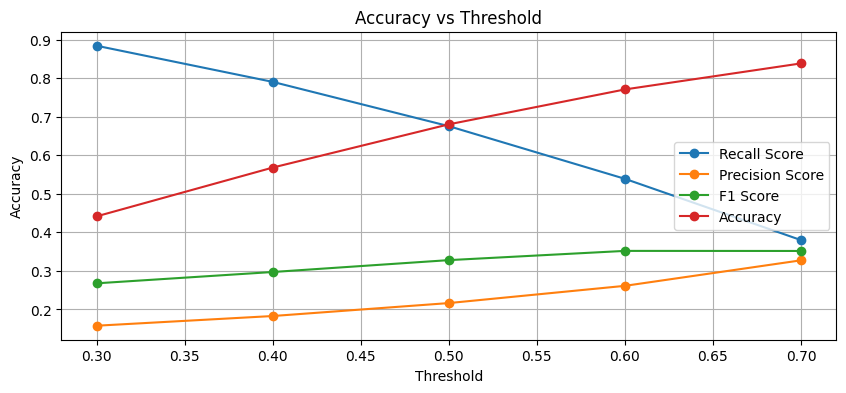

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("images/CatBoostClassifier.png")
plt.show()

In [31]:
pd.DataFrame({"recall": rs_list, "precision": ps_list, "f1-score": f1_list, "accuracy":ac_list}, index = np.arange(0.3,0.8,0.1))

,recall,precision,f1-score,accuracy
0.300,0.884,0.158,0.268,0.441
0.400,0.790,0.183,0.297,0.568
0.500,0.675,0.217,0.328,0.680
0.600,0.539,0.261,0.352,0.771
0.700,0.380,0.327,0.352,0.838
